In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lmfit import Model 
from functions import * 
pd.set_option('display.precision', 18)

In [2]:
be_3po_path = '/home/aldiyar/extrapolation/new-dataset/be_3po_test.csv'
be_3po = upload_basis(be_3po_path)
be_3po_err = upload_error(be_3po_path)
be_3po_init = be_3po.head(4)

In [3]:
be_3po_large = upload_df('/home/aldiyar/extrapolation/large-dataset/Be_3Po.csv')
be_3po_large_init = be_3po_large[:-1]
be_3po_large_last = be_3po_large.tail(1)

In [4]:
be_3se_01 = upload_basis('/home/aldiyar/extrapolation/new-dataset/be_3se_01_test.csv')
be_3se_01_init = be_3se_01.head(4)
be_3se_01_err = upload_error('/home/aldiyar/extrapolation/new-dataset/be_3se_01_test.csv')

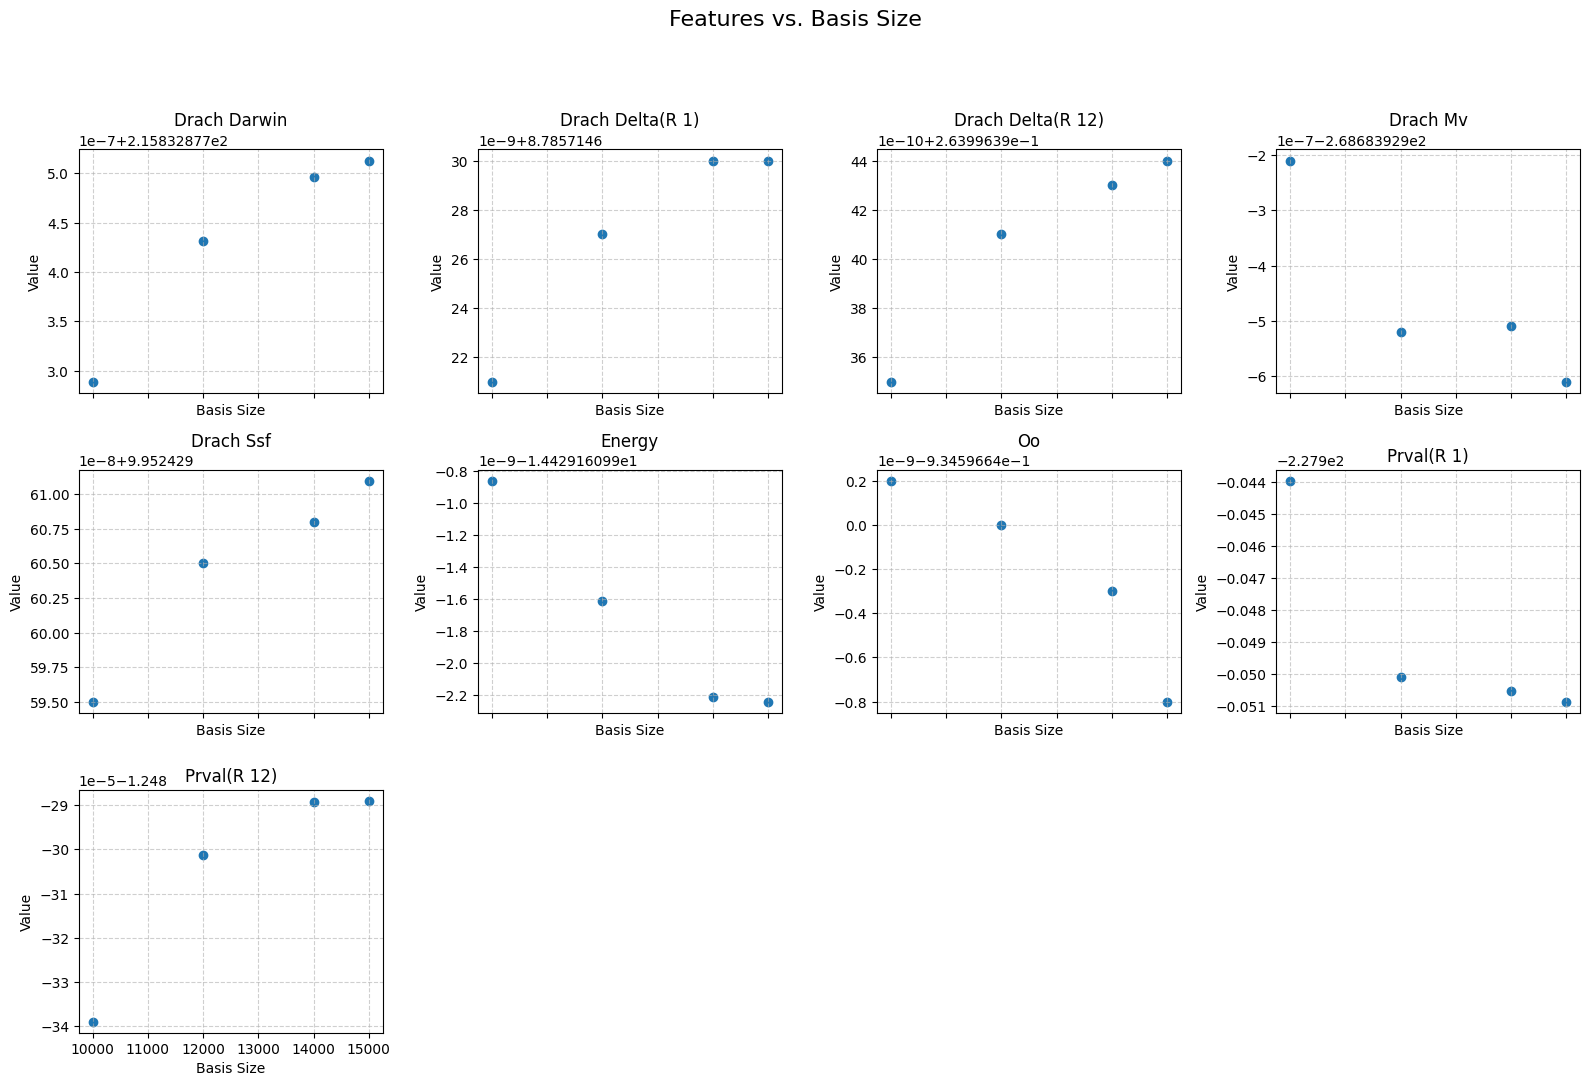

In [32]:
graph(be_3se_01_init)

In [ ]:
from scipy.optimize import least_squares, lsq_linear

class VarProIRLS:
    def __init__(self, df, x_col, y_col, err_df=None, b_init=None):
        self.raw_x = df[x_col].values.astype(float)
        self.raw_y = df[y_col].values.astype(float)
        self.x_col = x_col
        self.y_col = y_col
        self.err_df = err_df 
        
        # Sort data by X
        idx = np.argsort(self.raw_x)
        self.raw_x = self.raw_x[idx]
        self.raw_y = self.raw_y[idx]

        self.x_min = self.raw_x.min()
        self.x_max = self.raw_x.max()
        self.range_x = self.x_max - self.x_min
        if self.range_x == 0: 
            self.range_x = 1.0
        
        # --- TREND DETECTION ---
        slope, _ = np.polyfit(self.raw_x, self.raw_y, 1)
        self.is_increasing = slope > 0
        # --------------------------------

        self.override_b_init = b_init
        self.b_init = 1.0
        self.results = {}

    def _setup_model(self, model_type):
        self.model_type = model_type
        if self.model_type in ['power_law', 'sqrt_exponential']:
            safe_x = np.maximum(self.raw_x, self.x_max * 1e-6)
            self.t_scaled = safe_x / self.x_max
        else:
            self.t_scaled = (self.raw_x - self.x_min) / self.range_x
            
        if self.override_b_init is not None:
            self.b_init = self.override_b_init
        else:
            self.b_init = self._grid_search_initialization()

    def _get_A_bounds(self):
        """Only constrain A based on curve direction, C is unconstrained."""
        if self.is_increasing:
            lb = [-np.inf, -np.inf]
            ub = [np.inf, 0]
        else: 
            lb = [-np.inf, 0]
            ub = [np.inf, np.inf]
        return lb, ub

    def _grid_search_initialization(self):
        grid_B = np.linspace(1, 100, 10000) 
        best_ssr = np.inf
        best_B = 1.0
        
        lb, ub = self._get_A_bounds()
        
        for b_val in grid_B: 
            phi = self._compute_basis(b_val, self.t_scaled)
            
            try:
                res = lsq_linear(phi, self.raw_y, bounds=(lb, ub), method='bvls')
                y_pred = np.dot(phi, res.x)
                ssr = np.sum((self.raw_y - y_pred)**2)
            except:
                ssr = np.inf
            
            if ssr < best_ssr:
                best_ssr = ssr
                best_B = b_val
                
        return best_B

    def _compute_basis(self, B, t):
        phi = np.zeros((len(t), 2))
        phi[:, 0] = 1.0
        if self.model_type == 'exponential':
            phi[:, 1] = np.exp(-B * t)
        elif self.model_type == 'sqrt_exponential':
            phi[:, 1] = np.exp(-B * np.sqrt(t))
        elif self.model_type == 'power_law': 
            phi[:, 1] = np.power(t, -B)
        return phi

    def _compute_model_weights(self, B, t):
        # Calculate raw components first
        if self.model_type == 'exponential':
            log_w = B * t
        elif self.model_type == 'sqrt_exponential': 
            log_w = B * np.sqrt(t)
        elif self.model_type == 'power_law': 
            t_safe = np.maximum(t, 1e-12)
            log_w = B * np.log(t_safe)
        
        # Multiply by 2 because we want w^2 (inverse variance approximation)
        log_w = 2.0 * log_w
        
        # Normalize in log-space: subtract max log value
        # This guarantees the largest weight is exactly 1.0
        max_log_w = np.max(log_w)
        normalized_w = np.exp(log_w - max_log_w)
        
        return normalized_w

    def _solve_varpro_step(self, weights, start_b=None):
        y_w = self.raw_y * np.sqrt(weights)
        if start_b is None:  
            start_b = self.b_init
        
        lb, ub = self._get_A_bounds()

        def residual_func(alpha_curr):
            phi = self._compute_basis(alpha_curr[0], self.t_scaled)
            phi_w = phi * np.sqrt(weights)[:, np.newaxis]
            res_lin = lsq_linear(phi_w, y_w, bounds=(lb, ub), method='bvls')
            y_model = np.dot(phi, res_lin.x)
            return (self.raw_y - y_model) * np.sqrt(weights)

        res_opt = least_squares(residual_func, x0=[start_b], bounds=(1, np.inf), 
                                method='trf', loss='soft_l1')
        
        best_B = res_opt.x[0]
        phi = self._compute_basis(best_B, self.t_scaled)
        phi_w = phi * np.sqrt(weights)[:, np.newaxis]
        final_lin = lsq_linear(phi_w, y_w, bounds=(lb, ub), method='bvls')
        
        return best_B, final_lin.x[0], final_lin.x[1]

    def fit_irls(self, max_iter=100, tol=1e-8, damping=0.5, models=None, verbose=True, compute_uq=True, max_weight_ratio=10):
        if models is None: 
            models = ['exponential', 'sqrt_exponential', 'power_law']
        
        for model in models: 
            self._setup_model(model)
            if verbose:
                print(f"\n--- Fitting Model: {self.model_type} ---")
                print(f"{'Iter':<5} | {'B (Decay)':<12} | {'C (Asymptote)':<15} | {'Weight Ratio':<25}")
                print("-" * 65)

            current_weights = np.ones(len(self.raw_x))
            prev_C = np.inf
            current_B_guess = self.b_init
            
            final_B, final_C, final_A = 0, 0, 0

            for k in range(max_iter):
                B, C, A = self._solve_varpro_step(current_weights, start_b=current_B_guess)
                current_B_guess = B
                final_B, final_C, final_A = B, C, A

                if abs(C - prev_C) < tol and k > 0:
                    if verbose:
                        print("-" * 65)
                        print(f"Converged at iteration {k}")
                    break
                prev_C = C

                new_weights = self._compute_model_weights(B, self.t_scaled)
                
                # --- NEW LOGIC: Cap the ratio of weights ---
                # 1. Weights are already normalized so max is 1.0. 
                # 2. We just need to make sure the minimum weight isn't too small.
                min_allowed_weight = 1.0 / max_weight_ratio
                new_weights = np.maximum(new_weights, min_allowed_weight)
                # -------------------------------------------

                current_weights = (1 - damping) * current_weights + damping * new_weights
                
                if verbose: 
                    w_ratio = 1.0 / (np.min(current_weights) + 1e-12)
                    print(f"{k: <5} | {B:<12.6f} | {C: <15.6f} | {w_ratio:<25.2f}")

            phi = self._compute_basis(final_B, self.t_scaled)
            y_pred = final_C + final_A * phi[:, 1]
            ssr = np.sum((self.raw_y - y_pred)**2)
            
            dof = max(1, len(self.raw_y) - 1)
            sigma_noise = np.sqrt(ssr / dof)

            self.results[model] = {
                'B': final_B, 'C': final_C, 'A': final_A, 
                'ssr': ssr, 't_scaled': self.t_scaled.copy(),
                'sigma_noise': sigma_noise,
                'y_pred': y_pred,
                'final_weights': current_weights
            }
        
        if compute_uq and len(self.results) > 0:
            self.estimate_monte_carlo_uncertainty()
            
        return self.results

    def estimate_monte_carlo_uncertainty(self, n_samples=30):
        for model_name, res in self.results.items():
            y_pred = res['y_pred']
            sigma_noise = res['sigma_noise']
            warm_start_b = res['B']
            final_weights = res['final_weights']
            
            mc_Cs = []
            
            w_max = np.max(final_weights)
            if w_max == 0:
                 noise_scale_factors = np.ones_like(final_weights)
            else:
                 noise_scale_factors = final_weights / w_max
            
            for i in range(n_samples):
                base_noise = np.random.normal(0, sigma_noise, size=len(y_pred))
                weighted_noise = base_noise * noise_scale_factors
                y_synthetic = y_pred + weighted_noise
                
                sub_df = pd.DataFrame({self.x_col: self.raw_x, self.y_col: y_synthetic})
                sub_solver = VarProIRLS(sub_df, self.x_col, self.y_col, b_init=warm_start_b)
                
                sub_solver.fit_irls(models=[model_name], verbose=False, compute_uq=False)
                
                if model_name in sub_solver.results:
                    mc_Cs.append(sub_solver.results[model_name]['C'])
            
            q75, q25 = np.percentile(mc_Cs, [75, 25])
            sigma_robust = (q75 - q25) / 1.35
            
            if sigma_robust < 1e-12:
                sigma_robust = np.std(mc_Cs)
                
            self.results[model_name]['sigma_mc'] = sigma_robust

    def plot(self, truth_val=None):
        if not self.results: 
            return
        
        plt.figure(figsize=(12, 7))
        plt.plot(self.raw_x, self.raw_y, 'ko', label='Data', zorder=5, markersize=6)
        
        colors = {'exponential': 'blue', 'sqrt_exponential': 'orange', 'power_law': 'green'}
        labels = {'exponential': 'Exp($e^{-Bx}$)', 'sqrt_exponential': 'SqrtExp($e^{-B\\sqrt{x}}$)', 'power_law': 'Power($x^{-B}$)'}
        
        print("\n" + "="*80)
        print(f"{'Model':<20} | {'C (Asymptote)':<15} | {'MC Uncertainty':<20} | {'Diff from Truth'}")
        print("="*80)

        for model, res in self.results.items():
            C = res['C']
            sigma = res.get('sigma_mc', 0.0)
            
            diff_str = "-"
            if truth_val is not None:
                diff_str = f"{abs(C - truth_val):.2e}"
            
            print(f"{model:<20} | {C:<15.9f} | {sigma:<20.2e} | {diff_str}")
            
            x_plot = np.linspace(self.x_min, self.x_max * 1.5, 200)
            
            if model in ['power_law', 'sqrt_exponential']: 
                t_plot = x_plot / self.x_max
            else: 
                t_plot = (x_plot - self.x_min) / self.range_x
            
            self.model_type = model
            phi_plot = self._compute_basis(res['B'], t_plot)
            y_plot = C + res['A'] * phi_plot[:, 1]
            
            plt.plot(x_plot, y_plot, '-', color=colors[model], linewidth=2, alpha=0.8, label=f"{labels[model]}")
            
            plt.fill_between([self.x_min, self.x_max * 1.5], 
                             C - sigma, C + sigma, 
                             color=colors[model], alpha=0.1)
            
            plt.axhline(C, color=colors[model], linestyle='--', alpha=0.3)

        if truth_val is not None: 
            plt.axhline(truth_val, color='r', linestyle=':', linewidth=2, label=f'Truth ({truth_val:.8f})')
            
            if self.err_df is not None and self.y_col in self.err_df.columns:
                try:
                    truth_err = self.err_df[self.y_col].values[-1]
                    plt.fill_between([self.x_min, self.x_max * 1.5], 
                                     truth_val - truth_err, truth_val + truth_err, 
                                     color='r', alpha=0.15, zorder=0,
                                     label=f'Truth Error (±{truth_err:.1e})')
                except IndexError:
                    print(f"Warning: Could not extract error from {self.y_col} column.")
        
        plt.title(f"{self.y_col}")
        plt.xlabel("Basis Size")
        plt.ylabel("Value")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_ssr_profile(self, model_type='exponential', b_range=(0.1, 20), num_points=200):
        self._setup_model(model_type)
        b_grid = np.linspace(b_range[0], b_range[1], num_points)
        ssr_values = []
        lb, ub = self._get_A_bounds()
        for b_val in b_grid:
            phi = self._compute_basis(b_val, self.t_scaled)
            try:
                res = lsq_linear(phi, self.raw_y, bounds=(lb, ub), method='bvls')
                y_pred = np.dot(phi, res.x)
                ssr = np.sum((self.raw_y - y_pred)**2)
            except:
                ssr = np.nan
            ssr_values.append(ssr)

        plt.figure(figsize=(10, 6))
        plt.plot(b_grid, ssr_values, label=f'SSR Profile ({model_type})', color='purple')
        if model_type in self.results:
            opt_b = self.results[model_type]['B']
            opt_ssr = self.results[model_type]['ssr']
            plt.plot(opt_b, opt_ssr, 'r*', markersize=15, label=f'Final Solution (B={opt_b:.3f})')
        plt.title(f"SSR Landscape vs Parameter B ({model_type})")
        plt.xlabel("B (Decay Rate)")
        plt.ylabel("Sum of Squared Residuals (SSR)")
        plt.yscale('log')
        plt.grid(True, which="both", ls="-", alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


--- Fitting Model: exponential ---
Iter  | B (Decay)    | C (Asymptote)   | Weight Ratio             
-----------------------------------------------------------------
0     | 5.762376     | -227.950754     | 1.82                     
1     | 5.594094     | -227.950801     | 3.08                     
2     | 5.475333     | -227.950835     | 4.71                     
3     | 5.475333     | -227.950850     | 6.40                     
4     | 5.475333     | -227.950859     | 7.80                     
5     | 5.475333     | -227.950864     | 8.77                     
6     | 5.475333     | -227.950867     | 9.34                     
7     | 5.475333     | -227.950868     | 9.66                     
8     | 5.475333     | -227.950869     | 9.83                     
9     | 5.475333     | -227.950869     | 9.91                     
10    | 5.475333     | -227.950870     | 9.96                     
11    | 5.475333     | -227.950870     | 9.98                     
12    | 5.475333     | -227

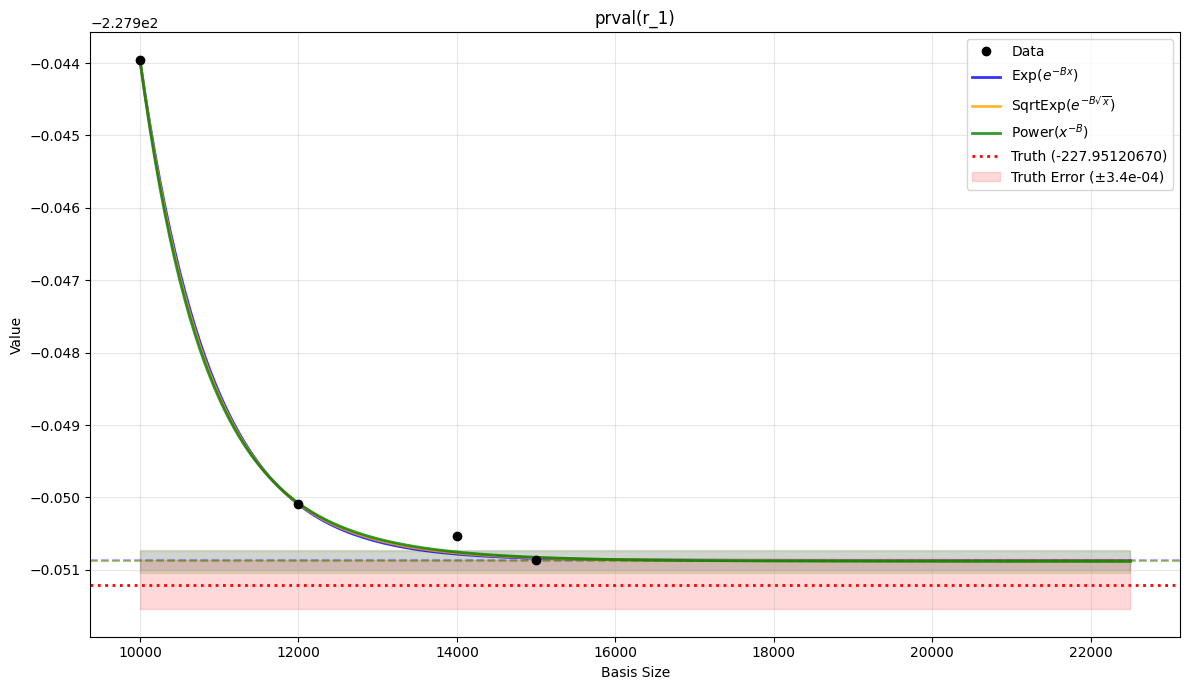

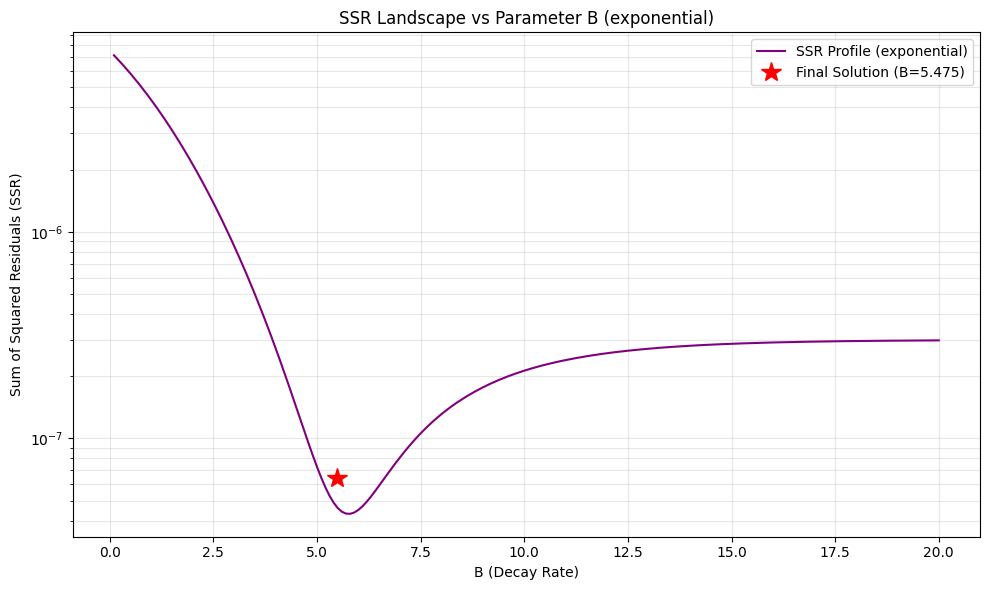

In [35]:
solver = VarProIRLS(be_3se_01_init, 'basis size', 'prval(r_1)', err_df=be_3se_01_err)
solver.fit_irls()
solver.plot(truth_val = -227.9512067)
solver.plot_ssr_profile()

In [33]:
be_3se_01

,basis size,Energy,drach_MV,OO,drach_SSF,drach_delta(r_1),drach_delta(r_12),prval(r_1),prval(r_12),drach_Darwin
0,10000,-14.429160990859999814,-268.683929209999973864,-0.934596639799999962,9.952429594999999907,8.785714621000000335,0.263996393499999982,-227.943958299999991368,-1.248338970000000048,215.832877289000009569
1,12000,-14.429160991610000764,-268.683929519999992408,-0.934596639999999979,9.952429605000000734,8.785714627000000831,0.263996394099999976,-227.950096199999990176,-1.248301251000000001,215.832877430999985791
2,14000,-14.429160992210000813,-268.683929509999984475,-0.934596640300000003,9.952429607999999206,8.785714629999999303,0.263996394299999992,-227.950530799999995679,-1.248289326999999949,215.832877496000008932
3,15000,-14.429160992239999928,-268.683929610000006960,-0.934596640800000045,9.952429610999999454,8.785714629999999303,0.263996394400000001,-227.950868799999994962,-1.248288958000000060,215.832877512999999681
4,20000,-14.429160992839999977,-268.683929719999980534,-0.934596641299999975,9.952429612999999620,8.785714630999999386,0.263996394500000009,-227.951206700000000183,-1.248277032999999925,215.832877529999990429


In [37]:
print(be_3po_err)

   basis size                Energy              MV          drach_MV  \
5       30000  0.000000001675999783  0.000465295281  0.00006465438651   

                  OO               SO1                SO2        delta(r_1)  \
5  0.000000007343776  0.00000002636368  0.000000160626702  0.00006694096232   

          delta(r_12)    drach_delta(r_1)  drach_delta(r_12)     prval(r_1)  \
5  0.0000000433012459  0.0000000233445298  0.000000002141673  0.00430493963   

       prval(r_12)       drach_Darwin  
5  0.0002518028299  0.000001639497583  
